# PRACTICE 2: PREDICTING PRODUCT SALES
## Workflow of Machine Learning Pipeline

### 1. Define Problem 
- Một tập đoàn bán lẻ quản lý chuỗi cửa hàng phân phối tại 10 trung tâm thương mại sầm uất nhất Istanbul (Thổ Nhĩ Kỳ) đang cần giải quyết bài toán quản lý luân chuyển hàng hóa và dòng tiền. Họ muốn dự đoán Doanh thu của từng giao dịch dựa trên thông tin nhân khẩu học của khách hàng và bối cảnh mua sắm.Việc dự đoán được mức chi tiêu này sẽ giúp phía doanh nghiệp đạt được 2 mục tiêu chiến lược:
    - **Tối ưu hóa hàng tồn kho:** Phân bổ chính xác số lượng và loại hàng hóa (Ví dụ: Công nghệ, Quần áo, Thực phẩm) cho từng trung tâm thương mại tại từng thời điểm cụ thể, nhằm giảm chi phí lưu kho và tránh tình trạng "cháy hàng"
    - **Chiến lược Marketing:** Thiết kế các chương trình khuyến mãi cá nhân hóa nhắm đúng vào tệp khách hàng tiềm năng (dựa trên độ tuổi, giới tính, phương thức thanh toán) để tối đa hóa lợi nhuận

### 2. Collect Data
- Bộ dữ liệu bao gồm 99,457 mẫu giao dịch (hóa đơn) với 10 cột thông tin chi tiết. Cấu trúc dữ liệu được chia làm 2 phần:
    - Các biến đặc trưng (Feaures - X):
        - **invoice_no:** Mã hóa đơn (Chuỗi định danh duy nhất cho mỗi giao dịch)
        - **customer_id:** Mã định danh khách hàng
        - **gender:** Giới tính của khách hàng (Male / Female)
        - **age:** Độ tuổi của khách hàng
        - **category:** Ngành hàng của sản phẩm được mua (Gồm 8 danh mục như Clothing, Cosmetics, Food & Beverage, Technology, Shoes, v.v.)
        - **quantity:** Số lượng sản phẩm được mua trong đơn hàng
        - **payment_method:** Phương thức thanh toán (Cash - Tiền mặt, Credit Card - Thẻ tín dụng, Debit Card - Thẻ ghi nợ)
        - **invoice_date:** Ngày thực hiện giao dịch mua sắm
        - **shopping_mall:** Tên chi nhánh trung tâm thương mại diễn ra giao dịch (Gồm 10 trung tâm lớn tại Istanbul như Kanyon, Mall of Istanbul, Metrocity...)
    - Biến mực tiêu (Target Variable - y):
        - **price:** Giá trị của đơn hàng (Đại diện cho Doanh thu/Revenue mang lại từ giao dịch đó). Đây là biến số liên tục (Continuous Variable) mà các mô hình học máy cần phải học quy luật và dự đoán

### 6. Model Selection
Để giải quyết bài toán dự đoán doanh thu, nhóm lựa chọn 3 trường phái thuật toán từ cơ bản đến nâng cao. Tất cả các mô hình dưới đây đều được nhóm Build from Scratch bằng Python thuần và Toán học ma trận (NumPy), tuyệt đối không sử dụng các class mô hình có sẵn của thư viện:
- Nhóm thuật toán Tuyến tính (Linear Models):
    - Linear Regression: Mô hình cơ sở, sử dụng thuật toán Gradient Descent để tìm trọng số tối ưu.
    - Ridge Regression: Nâng cấp từ Linear Regression, bổ sung hình phạt L2 (L2 Regularization) để khắc phục hiện tượng đa cộng tuyến và chống Overfitting
- Nhóm thuật toán Cây độc lập (Tree-based Model):
    - Decision Tree Regression: Mô hình rẽ nhánh phi tuyến tính. Có khả năng nắm bắt rất tốt các biến phân loại (như trung tâm thương mại, ngành hàng)
- Nhóm thuật toán Học kết hợp (Ensemble Models):
    - Random Forest Regression (Bagging): Xây dựng một "rừng" các cây quyết định độc lập trên các tập dữ liệu con (Bootstrap) để triệt tiêu phương sai (Variance) của cây đơn lẻ.
    - Gradient Boosting Regression (Boosting): Xây dựng các cây quyết định một cách tuần tự, cây sau học và sửa lỗi (Residuals) của cây trước. Đây là "vũ khí tối thượng" tối ưu hóa sai số (Bias) cực kỳ mạnh mẽ.

### 7. Model Training
Các bước thực hiện:
- Input:
    - Load dataset đã qua xử lý
    - Định nghĩa lưới tham số riêng cho thuật toán
- Train:
    - Tunning: Sử dụng CustomKfold và Grid tham số, CustomGridSearchCV. Hệ thống sẽ tự động chạy vòng lặp đánh giá chéo để tìm ra tổ hợp tham số giúp sai số nhỏ nhất
    - Fitting: Lấy bộ tham số chiến thắng (Best Parameters) khởi tạo một mô hình mới toanh. Sau đó train mô hình để nó hấp thụ tri thức 1 lần duy nhất trên toàn bộ tập train
- Output:
    - Best Estimator: Object mô hình tự code đã hoàn tất quá trình hội tụ toán học (Train xong)
    - Best Parameters: Bộ siêu tham số tốt nhất (Dictionary)
### 8. Model Evaluation
**Mục tiêu cốt lõi:** Đo lường sức mạnh dự đoán của các mô hình tự code trên tập dữ liệu chưa từng thấy (Tập Test) và tìm ra "Nhà Vô Địch" cuối cùng dựa trên các chỉ số mang ý nghĩa kinh doanh

Các bước thực hiện:
- Lấy kết quả dự đoán từ tập Test, Vì mô hình đã được huấn luyện trên dữ liệu Logarit, bắt buộc phải chuyển đổi cả kết quả dự đoán củ amodel và Ground Truth về lại đơn vị Tiền tệ thực tế trước khi tính toán sai số.
- Tính toán metrics:
    - MAE (Mean Absolute Error): Tính xem trung bình mô hình dự đoán lệch bao nhiêu tiền cho mỗi hóa đơn. (Đây là chỉ số dễ hiểu nhất để báo cáo cho Ban Giám đốc)
    - RMSE (Root Mean Squared Error): Chỉ số này phạt rất nặng các trường hợp mô hình dự đoán sai lệch quá lớn (Outlier prediction)
    - R-Squared ($R^2$): Đánh giá xem mô hình giải thích được bao nhiêu phần trăm (%) sự biến động của doanh thu thực tế
- Sau khi tính toán xong đóng gói thành arifacts (Bao gồm Mô hình gốc, Bộ tham số tốt nhất, và 3 chỉ số MAE, RMSE, R2)
- Tổng hợp lại để chọn ra model tốt nhất

### 3. Explore Data Analysis (EDA)
- Input: Raw dataset chưa qua xử lý
- Output: HTML EDA Report

**Mục tiêu cốt lõi:**
- Hiểu cấu trúc và kiểu dữ liệu của các đặc trưng mua sắm
- Phát hiện các giá trị khuyết thiếu và các điểm ngoại lai
- Xác định được các quy luật, mối quan hệ trong hành vi mua sắm của khách hàng (Ví dụ: Giới tính nào chi tiêu nhiều hơn? Ngành hàng nào mang lại doanh thu cao nhất?)
- Kiểm tra phân phối trước khi thực hiện modeling
- Kiểm địch chất lượng và kiểm tra các lỗi nhập liệu của từ raw dataset

**Các bước thực hiện chi tiết:**
- Data Overview
    - Check số lượng sample
    - Check số lượng feature
    - Check data type
    - Thống kê cơ bản cho các biến số
- Missing Data Analysis
    - Tính tỷ lệ missing theo từng feature một
    - Visualize Seaborn Heatmap nhỏ gọn để minh họa sự vắng mặt của dữ liệu
- Univariate Analysis
    - Nhóm Numerical (Tuổi và Giá trị đơn hàng): Visualize distribution plot để đánh giá độ lệch
    - Nhóm Categorical (Giới tính, Ngành hàng, Thanh toán): Visualize đồ thị tần suất để kiểm tra độ cân bằng class
- Bivariate/Multivariate Analysis
    - Numerical vs Numerical:
        - Sử dụng Ma trận tương quan để kiểm tra hiện tượng đa cộng tuyến (Ví dụ: age và quantity có tương quan với nhau không ?, ...)
        - Sử dụng Scatter Plots để xem xét xu hướng tuyến tính giữa các biến số
    - Categorical vs Numerical:
        - Sử dụng Boxplot và Barplot để trả lời các câu hỏi về doanh thu
            - Ngành hàng (category) nào mang lại giá trị hóa đơn (price) trung vị cao nhất?
            - Trung tâm thương mại (shopping_mall) nào có phổ doanh thu rộng nhất hoặc có nhiều hóa đơn giá trị cao (outliers) nhất?
    - Categorical vs Categorical:
        - Sử dụng Bảng chéo tần suất (Contingency tables / pd.crosstab), kết hợp vẽ Biểu đồ cột nhóm (Grouped Bar Charts) hoặc Biểu đồ cột chồng (Stacked Bar Charts). Nếu cần tính nghiêm ngặt về mặt thống kê, có thể áp dụng kiểm định Chi-square (Chi-square tests)
            - Insight nhân khẩu học: Phân bổ giới tính (gender) tại các shopping_mall khác nhau như thế nào? (Mall nào hút khách nam hơn, mall nào hút khách nữ hơn?)
            - Insight hành vi mua sắm: Sở thích chọn ngành hàng (category) có sự khác biệt giữa Nam và Nữ không?
            - Insight thanh toán: Khách hàng ưu tiên dùng phương thức thanh toán (payment_method) nào cho từng loại ngành hàng cụ thể?
- Outlier Detection
    - Tập trung vào biến price và quantity
    - Sử dụng phương pháp IQR để đếm số lượng hóa đơn có giá trị "bất thường" (mua quá nhiều hoặc giá quá cao)
- HTML Visualize Report

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [2]:
sns.set_theme(style="whitegrid")
data = pd.read_csv('./data/raw-data/customer_shopping_data.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


- Tập dữ liệu có kích thước khá lớn với 99,457 samples và 10 features
- Cột Non-Null Count đều hiển thị 99457 ở tất cả các feature. Điều này cho thấy bề mặt dữ liệu khá sạch, không có giá trị khuyết thiếu (Null/NaN) rõ ràng nào
- Tuy nhiên feature invoice_date (Ngày mua hàng) hiện đang mang kiểu dữ liệu là str (chuỗi văn bản/object)

-> Bắt buộc phải ép kiểu cột này về định dạng Datetime (Thời gian) thì mới có thể trích xuất được các Feature như Ngày, Tháng, Năm, Cuối tuần ở giai đoạn sau

In [5]:
display(data.describe().round(2))

,age,quantity,price
count,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26
std,14.99,1.41,941.18
min,18.00,1.00,5.23
25%,30.00,2.00,45.45
50%,43.00,3.00,203.30
75%,56.00,4.00,1200.32
max,69.00,5.00,5250.00


- Số lượng mua hàng biến thiên từ 1 đến 5 sản phẩm/đơn hàng, trung bình là 3. Dữ liệu rất sạch, không có số âm vô lý
- Độ tuổi khách hàng dao động từ 18 đến 69 tuổi, độ tuổi trung bình là 43. Không có tuổi bị nhiễu
- Doanh thu hóa đơn đang có dấu hiệu bị méo mó vì trung bình một đơn hàng trị giá $689.26 Lira, nhưng mức trung vị lại chỉ có $203.30. Sự chênh lệch khổng lồ giữa Mean và Median, cộng với mức Max lên tới $5250.00, cho thấy khả năng phân phối của Doanh thu bị lệch phải và chứa rất nhiều Outliers (Khách sộp mua đồ đắt tiền)

-> Bắt buộc phải thực hiện Log-Transform và dùng phương pháp IQR để cắt bỏ Outliers

In [7]:
display(data.describe(include=['object', 'category']))

C:\Users\minhchi\AppData\Local\Temp\ipykernel_23368\1997706906.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include=['object', 'category']))


,invoice_no,customer_id,gender,category,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457,99457,99457,99457
unique,99457,99457,2,8,3,797,10
top,I138884,C241288,Female,Clothing,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,34487,44447,159,19943


- Tại cột invoice_no và customer_id cho thấy có đúng 99,457 giá trị duy nhất (Unique = 99457). Tức là mỗi dòng là 1 khách hàng mới, không có ai mua lặp lại 2 lần. Hai biến này mang tính chất ID định danh, không có giá trị học máy
- Chân dung tệp khách hàng
    - Giới tính Nữ chiếm ưu thế áp đảo (Top = Female với 59,482 hóa đơn ~ 60%)
    - Ngành hàng bán chạy nhất là Quần áo (Clothing) với 34,487 đơn (Chiếm ~35%)
    - Ngành hàng bán chạy nhất là Quần áo (Clothing) với 34,487 đơn (Chiếm ~35%)
    - Địa điểm đông khách nhất là Mall of Istanbul (19,943 đơn)
-> Drop 2 cột invoice_no và customer_id tại bước Data Cleaning

In [10]:
# Tính toán số lượng và tỷ lệ % missing
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100

missing_table = pd.DataFrame({
    'Số lượng Missing': missing_data, 
    'Tỷ lệ (%)': missing_percent
})

In [11]:
display(missing_table.sort_values(by='Tỷ lệ (%)', ascending=False))

,Số lượng Missing,Tỷ lệ (%)
invoice_no,0,0.0
customer_id,0,0.0
gender,0,0.0
age,0,0.0
category,0,0.0
quantity,0,0.0
price,0,0.0
payment_method,0,0.0
invoice_date,0,0.0
shopping_mall,0,0.0


C:\Users\minhchi\AppData\Local\Temp\ipykernel_23368\3707565947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='viridis')


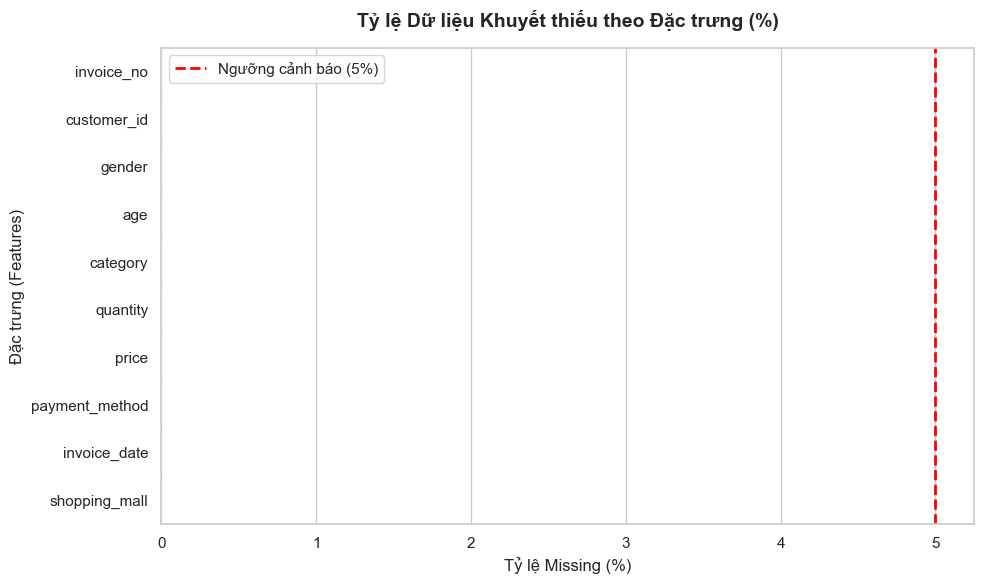

In [13]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='viridis')

plt.title('Tỷ lệ Dữ liệu Khuyết thiếu theo Đặc trưng (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ Missing (%)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)

plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Ngưỡng cảnh báo (5%)')
plt.legend()

plt.tight_layout()
plt.show()


🔸 Biến: AGE
   - Độ lệch (Skewness): 0.0090
   - Giá trị từng cột (Bin) trên biểu đồ:
     + Cột 1 [Từ   18.00 đến   23.10]:  11519 hóa đơn
     + Cột 2 [Từ   23.10 đến   28.20]:   9639 hóa đơn
     + Cột 3 [Từ   28.20 đến   33.30]:   9536 hóa đơn
     + Cột 4 [Từ   33.30 đến   38.40]:   9689 hóa đơn
     + Cột 5 [Từ   38.40 đến   43.50]:   9691 hóa đơn
     + Cột 6 [Từ   43.50 đến   48.60]:   9526 hóa đơn
     + Cột 7 [Từ   48.60 đến   53.70]:   9597 hóa đơn
     + Cột 8 [Từ   53.70 đến   58.80]:   9343 hóa đơn
     + Cột 9 [Từ   58.80 đến   63.90]:   9488 hóa đơn
     + Cột 10 [Từ   63.90 đến   69.00]:  11429 hóa đơn

🔸 Biến: QUANTITY
   - Độ lệch (Skewness): -0.0013
   - Giá trị từng cột (Bin) trên biểu đồ:
     + Cột 1 [Từ    1.00 đến    1.40]:  19767 hóa đơn
     + Cột 2 [Từ    1.40 đến    1.80]:      0 hóa đơn
     + Cột 3 [Từ    1.80 đến    2.20]:  19828 hóa đơn
     + Cột 4 [Từ    2.20 đến    2.60]:      0 hóa đơn
     + Cột 5 [Từ    2.60 đến    3.00]:      0 hóa đơn
     + Cộ

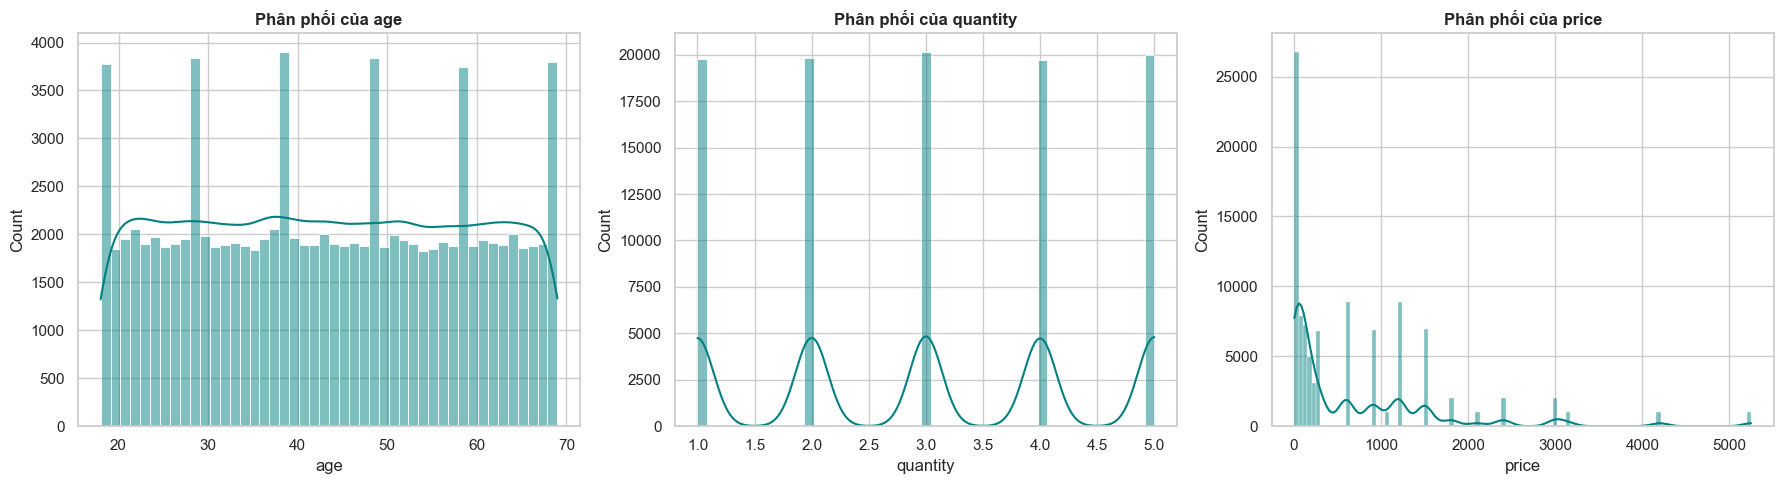

In [25]:
# Nhóm Numerical (Tuổi và Giá trị đơn hàng)
num_cols = ['age', 'quantity', 'price']
for col in num_cols:
    print(f"\n🔸 Biến: {col.upper()}")
    # Tính độ lệch
    print(f"   - Độ lệch (Skewness): {data[col].skew():.4f}")
    
    # Chia thành 10 cột (bins) giống như vẽ histplot và đếm số lượng mẫu trong mỗi cột
    counts, bin_edges = np.histogram(data[col].dropna(), bins=10)
    
    print("   - Giá trị từng cột (Bin) trên biểu đồ:")
    for i in range(len(counts)):
        print(f"     + Cột {i+1} [Từ {bin_edges[i]:>7.2f} đến {bin_edges[i+1]:>7.2f}]: {counts[i]:>6} hóa đơn")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

Dựa vào kết quả visualize phân bố trên:
- Tuổi tác khách hàng phân bố đồng đều
    - Độ lệch (Skewness) = 0.0090: Con số này tiệm cận 0, chứng tỏ tuổi tác của khách hàng có phân phối gần như đối xứng hoàn hảo, không bị lệch về nhóm người già hay người trẻ
    - Lượng khách hàng dàn trải cực kỳ đều ở mọi độ tuổi (khoảng 9,500 hóa đơn cho mỗi dải 5 tuổi). Đặc biệt, tập khách hàng hơi nhỉnh hơn một chút ở hai đầu mút: nhóm trẻ (18-23 tuổi) với 11,519 hóa đơn và nhóm lớn tuổi (64-69 tuổi) với 11,429 hóa đơn

-> Các trung tâm thương mại trong tập dữ liệu phục vụ tốt cho mọi lứa tuổi. Không có sự thống trị của bất kỳ thế hệ nào (Gen Z, Millennials hay Boomers đều mua sắm ngang nhau)

- Số lượng sản phẩm phân bố cân bằng tuyệt đối
    - Độ lệch (Skewness) = -0.0013: Hoàn toàn không bị lệch
    - Việc xuất hiện các mốc "0 hóa đơn" xen kẽ chứng minh rằng quantity là một biến số nguyên rời rạc. Khách hàng chỉ mua đúng 1, 2, 3, 4, hoặc 5 sản phẩm. Đặc biệt, số lượng hóa đơn cho mỗi mức mua (từ 1 đến 5) là bằng nhau chằn chặn (dao động sát mốc 20,000 hóa đơn mỗi loại)

-> Có thể giới hạn của giỏ hàng là 5 sản phẩm/đơn. Sự phân bổ đều tăm tắp này cho thấy không có xu hướng khách hàng thích mua lẻ 1 món hay mua sỉ 5 món

- Tại giá trị hóa đơn
    - Độ lệch (Skewness) = 2.2474: Độ lệch dương rất lớn (> 1), đây là bằng chứng cho thấy feature price bị lệch phải cực kỳ nặng nề, dẫn đến tổng doanh thu cũng sẽ bị lệch phải
    - Hơn 57% tổng số hóa đơn (56,781 / 99,457) tập trung ở phân khúc bình dân (giá trị rất thấp, từ $5.23 đến $529.71)
        - Càng tiến về mức giá cao, số lượng hóa đơn càng rớt thảm hại. Tuy nhiên, tập dữ liệu vẫn xuất hiện những nhóm "Outlier" (Khách sộp) mua các đơn hàng xa xỉ: có 1001 đơn hàng trên $4200 và 1001 đơn hàng chạm mức đỉnh $5250
        
-> Phản ánh đúng thực tế ngành bán lẻ: Đa số khách hàng mua đồ dùng thiết yếu, giá rẻ (như đồ ăn, nước uống); chỉ một nhóm rất nhỏ mua hàng hiệu, đồ công nghệ đắt tiền. Vì phân bố lệch phải quá mạnh, nếu đưa nguyên gốc feature price vào mô hình Linear Regression, mô hình sẽ bị bias hoàn toàn. Nhóm bắt buộc phải thực hiện Log-Transform ở khâu Feature Engineering để kéo phân phối này về dạng hình chuông

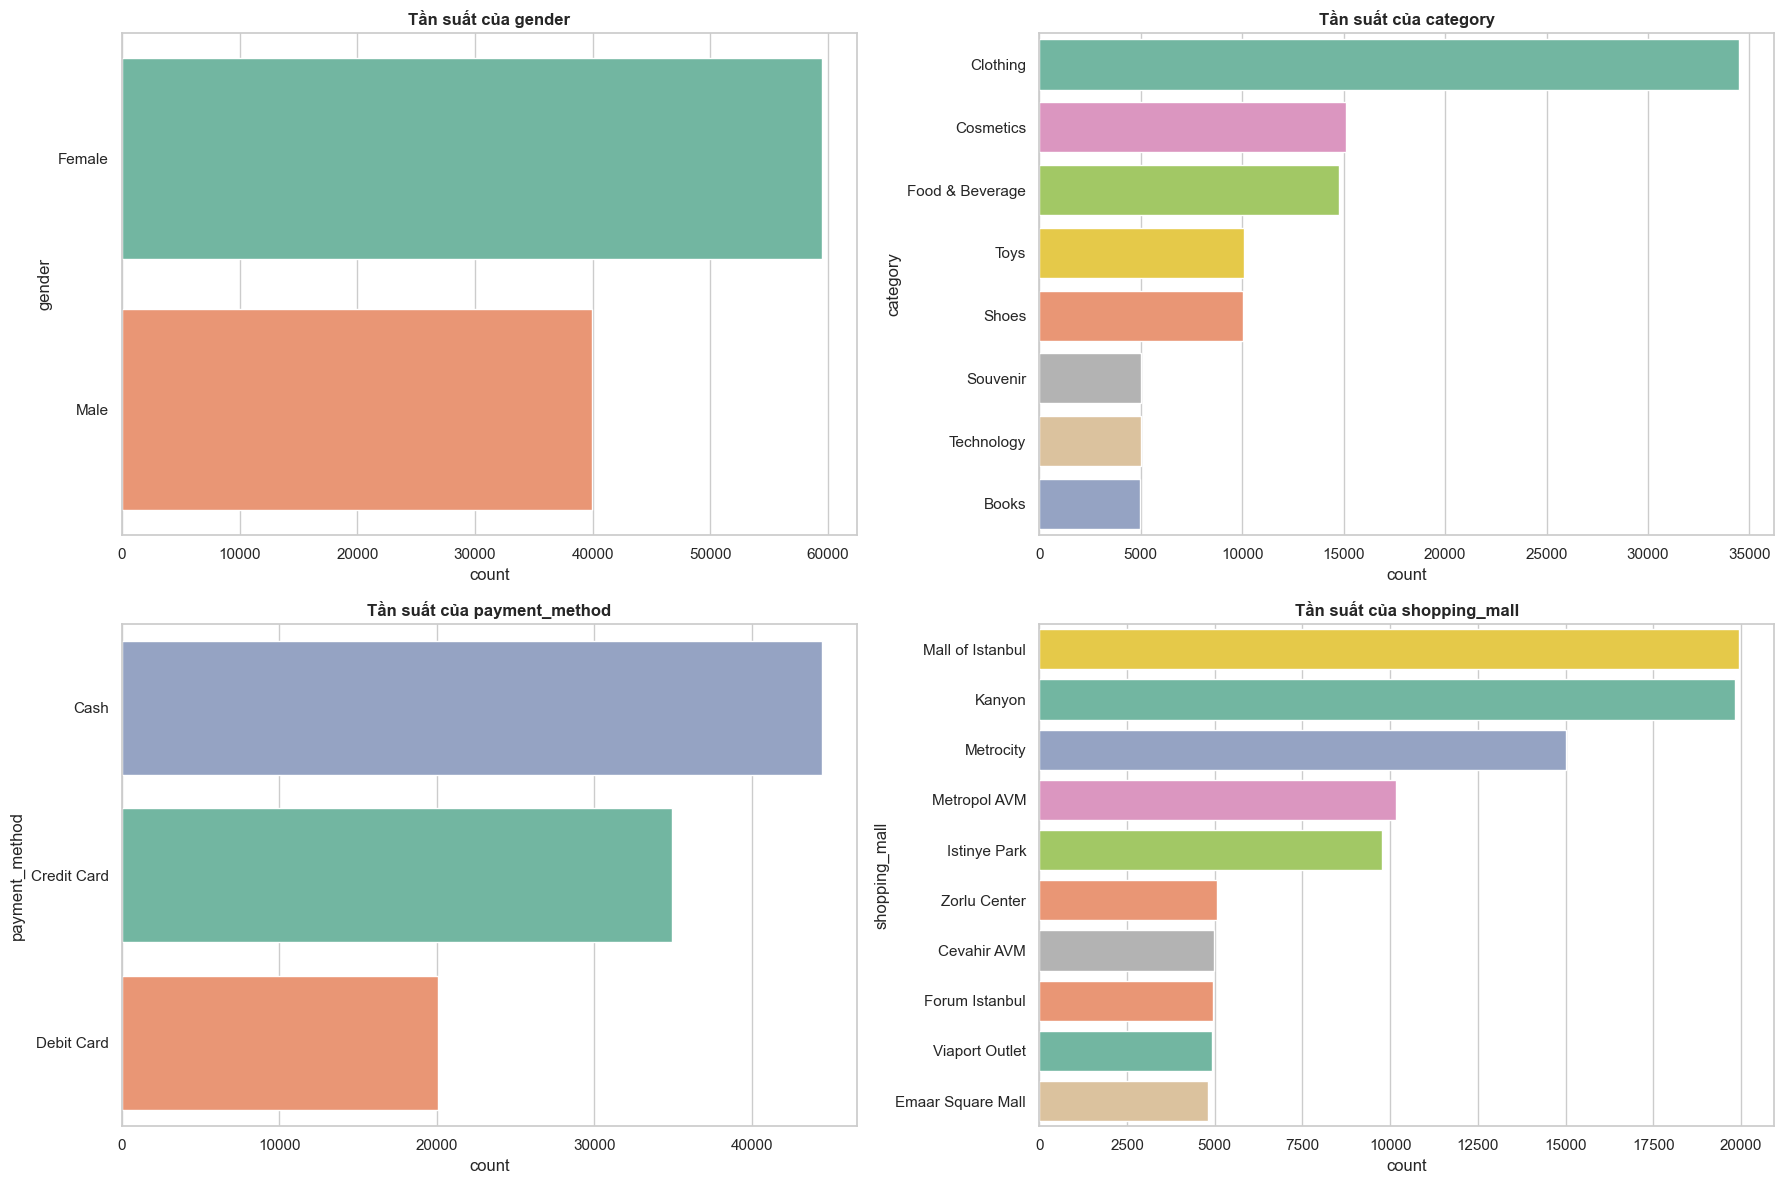

In [ ]:
# Nhóm Categorical (Giới tính, Ngành hàng, Thanh toán, Mall)
cat_cols = ['gender', 'category', 'payment_method', 'shopping_mall']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
    y=data[col], 
    hue=data[col],          # Chỉ định biến để phân màu
    ax=axes[i], 
    palette='Set2', 
    legend=False,         
    order=data[col].value_counts().index
)
    axes[i].set_title(f'Tần suất của {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa vào kết quả tần suất trên nhóm Categorical, ta có:
- Giới tính khách hàng:
    - Tập dữ liệu có sự chênh lệch (Imbalance) nhẹ giữa hai giới tính. Khách hàng Nữ (Female) chiếm ưu thế với gần 60.000 đơn hàng (~60%), trong khi Nam (Male) chỉ có khoảng 40.000 đơn hàng (~40%)

-> Phụ nữ là tệp khách hàng cốt lõi và là người đưa ra quyết định mua sắm chính tại các trung tâm thương mại này. Các chiến dịch Marketing nên ưu tiên thiết kế hình ảnh và thông điệp hướng tới phái Đẹp để tối ưu tỷ lệ chuyển đổi (Conversion Rate). Vì tỷ lệ 60:40 là một tỷ lệ mất cân bằng ở mức độ chấp nhận được nên không cần phải sử dụng các kỹ thuật cân bằng dữ liệu (như SMOTE hay Undersampling) vì nó vẫn phản ánh đúng tỷ lệ tự nhiên của tệp khách hàng mua lẻ

- Ngành hàng:
    - Dữ liệu chia thành 3 phân lớp rõ rệt:
        - Dẫn đầu: Clothing thống trị tuyệt đối với gần 35.000 đơn hàng (chiếm hơn 1/3 tổng lượng giao dịch)
        - Tầm trung: Mỹ phẩm (Cosmetics) và Đồ ăn thức uống (Food & Beverage) bám đuổi với 15.000 đơn mỗi loại; tiếp theo là Đồ chơi (Toys) và Giày dép (Shoes) với 10.000 đơn
        - Đặc thù/Niche: Đồ lưu niệm (Souvenir), Đồ công nghệ (Technology) và Sách (Books) nằm ở đáy bảng xếp hạng, chỉ đóng góp 5.000 đơn mỗi loại

-> Nhu cầu mua sắm tại Mall chủ yếu tập trung vào các mặt hàng may mặc và tiêu dùng nhanh. Các mặt hàng giá trị cao (Công nghệ) hoặc mua một lần (Sách, Đồ lưu niệm) có tần suất giao dịch rất thấp

- Phương thức thanh toán:
    - Tiền mặt (Cash) là phương thức thanh toán phổ biến nhất với hơn 40.000 giao dịch. Theo sau là Thẻ tín dụng (Credit Card) với khoảng 35.000 giao dịch. Thẻ ghi nợ (Debit Card) ít được sử dụng nhất (đúng 20.000 giao dịch)

-> Mặc dù công nghệ tài chính phát triển, nhưng một bộ phận rất lớn khách hàng vẫn giữ thói quen dùng tiền mặt. (Giả thuyết: Có thể đa số các đơn hàng tiền mặt thuộc về phân khúc giá rẻ như Đồ ăn/Nước uống. Chúng ta sẽ kiểm chứng giả thuyết này ở bước phân tích đa biến)

- Trung tâm thương mại:
    - Trong số 10 trung tâm thương mại, có sự phân bổ lưu lượng không đồng đều:
        - Top 3 "Ông lớn": Mall of Istanbul (~20.000 đơn), Kanyon (<20.000 đơn) và Metrocity (15.000 đơn) chiếm phần lớn "miếng bánh" thị phần
        - Nhóm bám đuổi: Metropol AVM và Istinye Park (quanh mốc 10.000 đơn)
        - Nhóm thấp nhất: Các Mall còn lại như Zorlu Center, Cevahir AVM, Forum Istanbul, Viaport Outlet đều nằm ở mốc 5.000 đơn, riêng Emaar Square Mall chạm đáy với lượng đơn thấp nhất (<5.000)

-> Vị trí địa lý và quy mô của Mall quyết định trực tiếp đến lưu lượng khách. Việc phân phối hàng hóa tồn kho phải được rót trọng tâm vào Top 3 Mall dẫn đầu để tránh đọng vốn tại các Mall vắng khách

In [7]:
data['revenue'] = data['price'] * data['quantity']
# Tạo ma trận tương quan cho các biến số học
num_df = data[['age', 'quantity', 'price', 'revenue']]
corr_matrix = num_df.corr()

In [8]:
display(corr_matrix.round(3))

,age,quantity,price,revenue
age,1.000,0.001,0.002,0.003
quantity,0.001,1.000,0.345,0.461
price,0.002,0.345,1.000,0.962
revenue,0.003,0.461,0.962,1.000


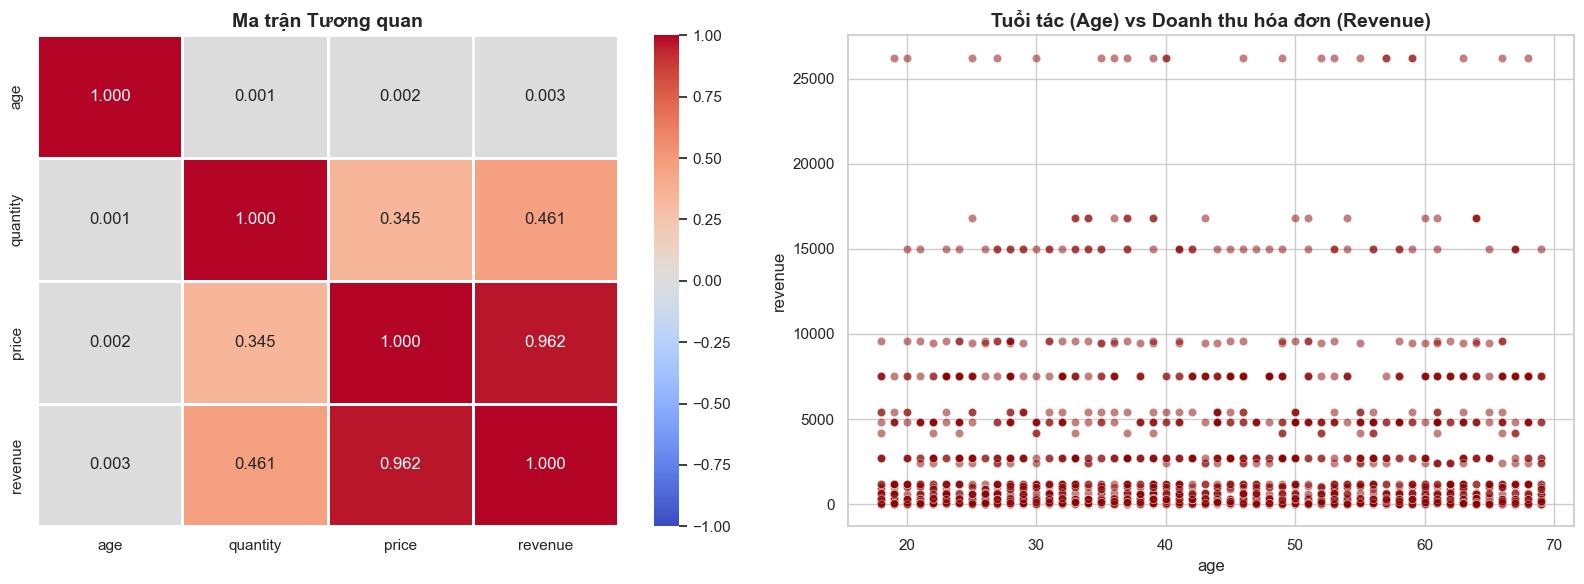

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Ma trận tương quan
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", 
            linewidths=1, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Ma trận Tương quan', fontsize=14, fontweight='bold')


# Scatter plot (Mối quan hệ giữa Tuổi và Doanh thu)
# Random 2000 sample để vẽ Scatter plot cho nhẹ
sample_df = data.sample(2000, random_state=42)
sns.scatterplot(data=sample_df, x='age', y='revenue', alpha=0.5, color='darkred', ax=axes[1])
axes[1].set_title('Tuổi tác (Age) vs Doanh thu hóa đơn (Revenue)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, cho thấy:
-  Tuổi tác hoàn toàn vô can đến Doanh thu (Correlation $\approx$ 0)
    - Hệ số tương quan giữa age và revenue là 0.003 (gần như bằng 0 tuyệt đối). Tương tự, age cũng không có quan hệ tuyến tính nào với quantity (0.001) hay price (0.002)

-> Tuổi tác không phải là nhân tố quyết định việc "chốt đơn" lớn hay nhỏ. Các chiến dịch Upsell (bán chéo, bán thêm) không nên chỉ tập trung vào nhóm khách hàng lớn tuổi (những người thường được mặc định là có tài chính tốt hơn), vì Gen Z trong tệp dữ liệu này cũng chịu chi không kém

Vì feature age có quan hệ tuyến tính cực yếu với $y$, thuật toán Linear/Ridge Regression sẽ đánh trọng số của biến này gần bằng 0. Do đó, thực hiện Rời rạc hóa (Binning) biến age thành các nhóm tuổi (Gen Z, Boomers...) ở khâu Feature Engineering có thể giúp mô hình bắt được các quy luật phi tuyến (nếu có)

- Nhìn vào Scatter plot (Tuổi vs Doanh thu), ta không thấy các chấm bi phân bổ ngẫu nhiên mà chúng xếp thành các đường kẻ ngang song song nhau

-> Điều này cho thấy trong dataset này có mức giá bán được cố định cho từng ngành hàng (Ví dụ: Tất cả đơn hàng Giày dép đều có cùng một mức giá cơ sở, tất cả Sách đều có cùng một giá). Khi lấy mức giá cố định này nhân với số lượng mua là các số nguyên rời rạc (1, 2, 3, 4, 5), kết quả doanh thu sinh ra sẽ tạo thành các bậc thang ngang

- Hệ số tương quan giữa giá bán và doanh thu cực kỳ cao (0.962), trong khi giữa quantity và revenue chỉ ở mức trung bình (0.461). Điều này cho thấy Doanh thu của trung tâm thương mại chủ yếu được kéo lên bởi việc bán các mặt hàng giá trị cao (như Công nghệ, Mỹ phẩm) chứ không phải nhờ việc khách hàng mua số lượng nhiều

In [11]:
display(data.groupby('category')['revenue'].mean().sort_values(ascending=False).round(2))

category
Technology         11581.74
Shoes               6632.79
Clothing            3305.50
Cosmetics            449.95
Toys                 394.61
Books                167.55
Souvenir             127.19
Food & Beverage       57.49
Name: revenue, dtype: float64

C:\Users\minhchi\AppData\Local\Temp\ipykernel_1424\2752860524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='revenue', y='category', ax=axes[0],
C:\Users\minhchi\AppData\Local\Temp\ipykernel_1424\2752860524.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='revenue', y='shopping_mall', ax=axes[1],


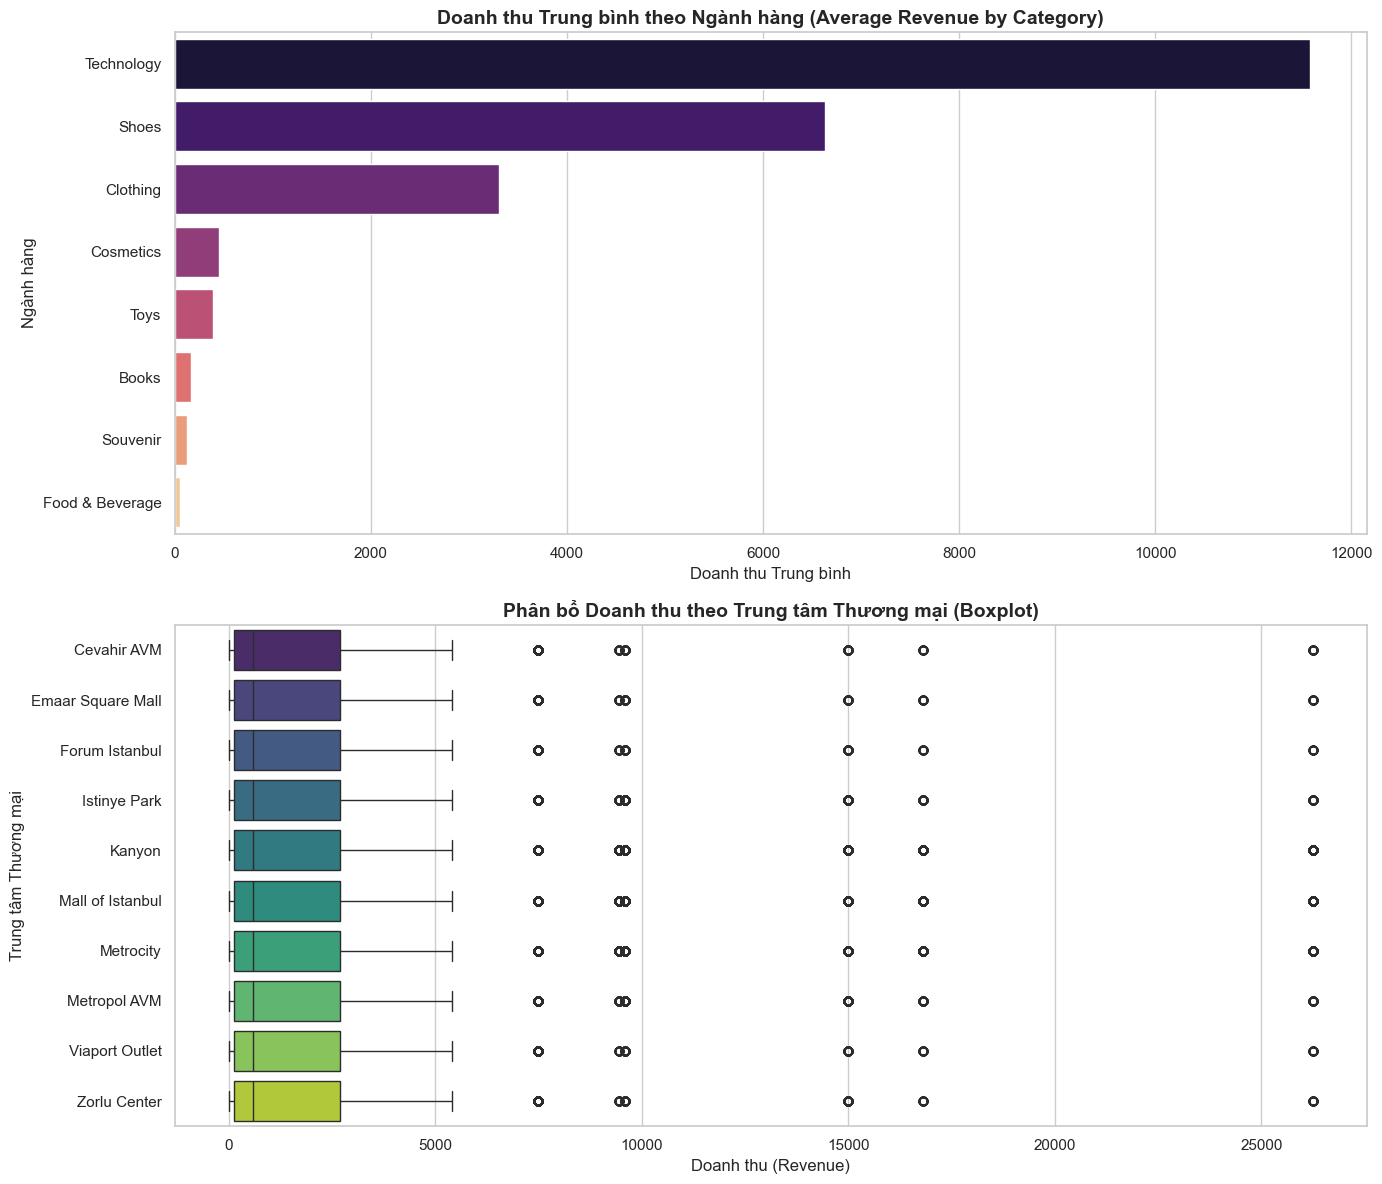

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Doanh thu theo Category
# Sắp xếp theo doanh thu trung bình giảm dần
category_order = data.groupby('category')['revenue'].mean().sort_values(ascending=False).index
sns.barplot(data=data, x='revenue', y='category', ax=axes[0], 
            palette='magma', order=category_order, errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Ngành hàng (Average Revenue by Category)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Doanh thu Trung bình', fontsize=12)
axes[0].set_ylabel('Ngành hàng', fontsize=12)

# Phân phối Doanh thu theo Shopping Mall
# Dùng Boxplot để xem Mall nào có nhiều hóa đơn Outlier (khách VIP) nhất
mall_order = data.groupby('shopping_mall')['revenue'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='revenue', y='shopping_mall', ax=axes[1], 
            palette='viridis', order=mall_order)
axes[1].set_title('Phân bổ Doanh thu theo Trung tâm Thương mại (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Doanh thu (Revenue)', fontsize=12)
axes[1].set_ylabel('Trung tâm Thương mại', fontsize=12)

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, cho thấy:
- Đối với category: Có một sự đối lập so với bước trước đó (Phân tích đơn biến) là trước đó Technology là ngành hàng được ít đơn nhất (nằm ở đáy bảng tần suất) nhưng khi phân tích đa biến thì Technology lại là ngành hàng mang về doanh thu trung bình 11,581 Lira / đơn hàng, cao gấp đôi vị trí số hai là Giày dép (6,632 Lira) và gấp gần 4 lần Quần áo (3,305 Lira). Ngược lại, ngành hàng Food & Beverage dù có lượng đơn hàng khổng lồ (Top 3) nhưng doanh thu mỗi đơn lại lẹt đẹt ở mức thấp nhất (57.49 Lira)

-> Quần áo và Đồ ăn là sản phẩm mồi giúp thu hút lưu lượng khách đến Mall thường xuyên. Còn Đồ Công nghệ và Giày dép mới là mấu chốt mang lại dòng tiền thực sự nên ta có thể đặt các cửa hàng Công nghệ ở gần khu vực Đồ ăn để kích thích nhu cầu mua sắm chéo. Từ đó ta cũng thấy rằng feature category có sức mạnh phân loại doanh thu cực tốt (Phân tầng rõ rệt từ 57 lên 11,581). Chắc chắn sau khi train xong, category sẽ là feature quan trọng cao nhất trong mô hình Random Forest

- Đối với shopping mall: Nhìn vào boxplot của 10 Shopping Mall, chúng ta thấy một hiện tượng cực kỳ đặc biệt: Tất cả các Mall đều có hình dáng biểu đồ giống hệt nhau. Mức trung vị nằm trên cùng một đường thẳng, và dải Outlier (các hóa đơn khủng) cũng dài y như nhau

-> Sức mua của khách hàng là hoàn toàn độc lập với vị trí địa lý. Một khách hàng bước vào Mall of Istanbul (nơi đông nhất) hay Emaar Square Mall (nơi vắng nhất) thì họ cũng sẽ chi tiêu một số tiền y hệt nhau. Vấn đề của các Mall vắng khách không phải là do tệp khách hàng ở đó nghèo, mà là do các chiến dịch thu hút người đến Mall chưa tốt

Vì feature shopping_mall không tạo ra sự khác biệt về doanh thu, mô hình học máy (đặc biệt là Regression) có khả năng cao sẽ đánh trọng số rất thấp cho feature này

In [13]:
display(data.groupby('gender')['revenue'].mean().round(2))

gender
Female    2525.25
Male      2534.05
Name: revenue, dtype: float64

In [14]:
display(data.groupby('payment_method')['revenue'].mean().round(2))

payment_method
Cash           2538.58
Credit Card    2521.46
Debit Card     2519.87
Name: revenue, dtype: float64

C:\Users\minhchi\AppData\Local\Temp\ipykernel_1424\2039565148.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='gender', y='revenue', ax=axes[0], palette='pastel', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_1424\2039565148.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='payment_method', y='revenue', ax=axes[1], palette='Set2', errorbar=None)


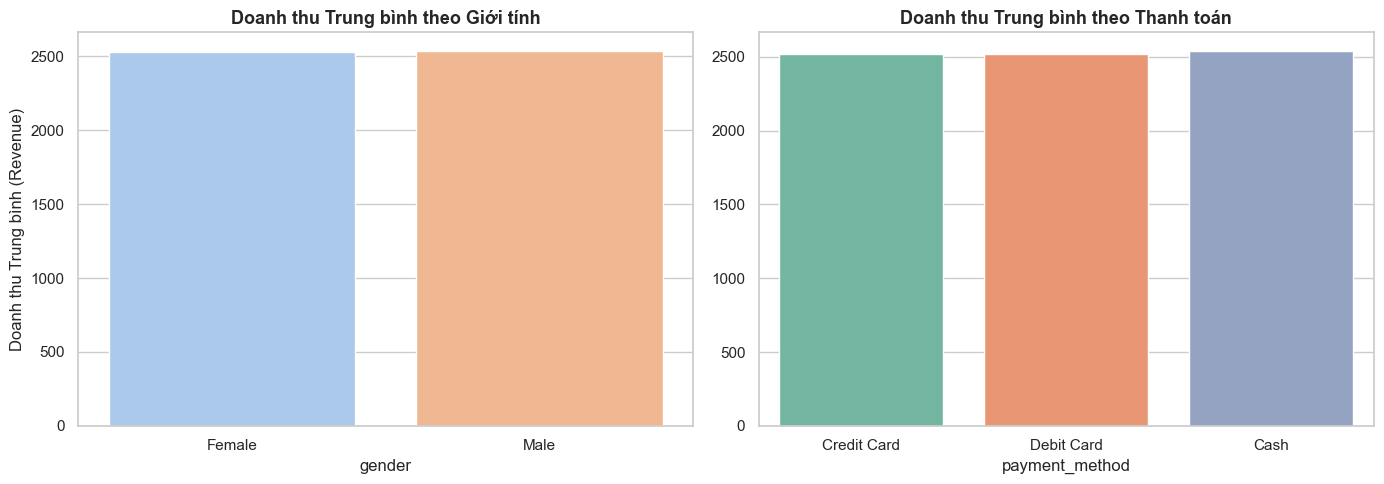

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Doanh thu theo Giới tính (Gender vs Revenue)
sns.barplot(data=data, x='gender', y='revenue', ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Giới tính', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Doanh thu Trung bình (Revenue)')

# Doanh thu theo Phương thức thanh toán (Payment vs Revenue)
sns.barplot(data=data, x='payment_method', y='revenue', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Doanh thu Trung bình theo Thanh toán', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, cho thấy:
- Khách hàng Nữ mang lại trung bình 2525.25 Lira/đơn, trong khi khách hàng Nam là 2534.05 Lira/đơn. Mức chênh lệch chưa tới 10 Lira (chỉ khoảng 0.3%) là hoàn toàn không có ý nghĩa về mặt thống kê

-> Mặc dù Nữ giới đi siêu thị nhiều hơn (chiếm 60% số lượng hóa đơn như đã phân tích trước đó), nhưng khi xét trên giá trị của từng giỏ hàng, Nam và Nữ chi tiêu hào phóng y hệt nhau. Vậy nhận định về "Phụ nữ đi shopping tốn nhiều tiền hơn Nam giới" hoàn toàn bị bác bỏ trong bộ dữ liệu này

Vì mức trung bình bằng nhau chằn chặn, feature gender độc lập sẽ có rất ít sức mạnh dự đoán trong các mô hình Hồi quy

- Đi ngược lại với suy nghĩ thông thường rằng "người dùng Thẻ tín dụng thường mua sắm bạo tay hơn", dữ liệu cho thấy Doanh thu trung bình của 3 hình thức (Cash, Credit, Debit) gần như bằng nhau tuyệt đối (dao động quanh mốc 2520 - 2538 Lira). Thậm chí Tiền mặt còn nhỉnh hơn một chút xíu

-> Khách hàng sử dụng phương thức thanh toán dựa trên thói quen cá nhân chứ không phụ thuộc vào độ lớn của hóa đơn. Khách hàng vẫn sẵn sàng xách theo hàng ngàn Lira tiền mặt để đi mua Đồ công nghệ hay Giày dép. Vậy tương tự như feature gender và shopping_mall, feature payment_method sẽ không mang lại nhiều trọng số cho mô hình. Việc dự đoán Doanh thu gần như sẽ đặt toàn bộ trọng trách lên vai feature category

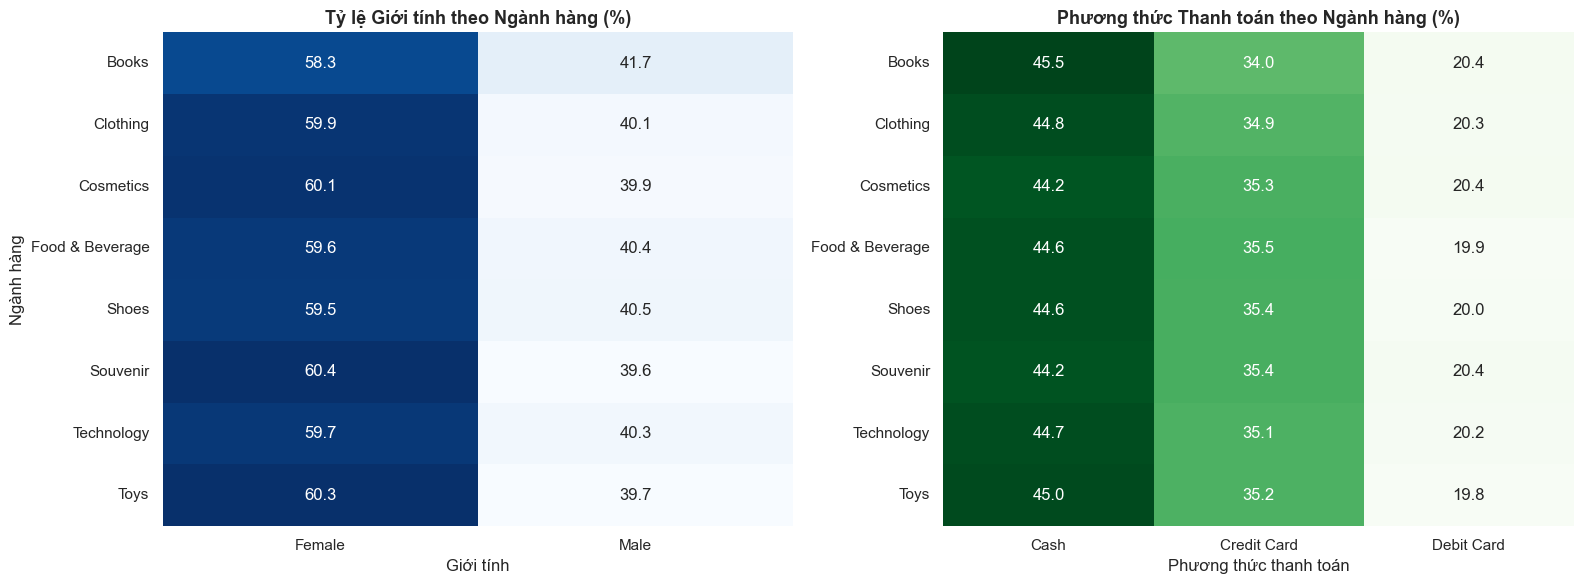

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Giới tính vs Ngành hàng (Gender vs Category)
# Dùng bảng chéo (crosstab) để tính tỷ lệ % khách Nam/Nữ trong từng ngành hàng
gender_cat = pd.crosstab(data['category'], data['gender'], normalize='index') * 100
sns.heatmap(gender_cat, annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title('Tỷ lệ Giới tính theo Ngành hàng (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ngành hàng')
axes[0].set_xlabel('Giới tính')

# Ngành hàng vs Phương thức thanh toán (Category vs Payment Method)
# Xem ngành hàng nào người ta hay quẹt thẻ, ngành nào hay dùng tiền mặt
pay_cat = pd.crosstab(data['category'], data['payment_method'], normalize='index') * 100
sns.heatmap(pay_cat, annot=True, fmt=".1f", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title('Phương thức Thanh toán theo Ngành hàng (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Phương thức thanh toán')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, cho thấy:
- Sự đồng nhất tuyệt đối, ở bất kỳ ngành hàng nào (từ Thời trang, Mỹ phẩm cho đến Đồ công nghệ), Nữ giới luôn chiếm khoảng 59.5% - 60.4% và Nam giới chiếm 39.6% - 40.5%

-> Khách hàng Nam và Nữ có chung một "tỉ lệ phân bổ sở thích" khi bước vào Mall. Nhận định rằng "Chỉ có phụ nữ mới hay mua Mỹ phẩm" hay "Đàn ông mua Đồ công nghệ (Technology) nhiều hơn" hoàn toàn bị bác bỏ. Tỷ lệ 60:40 này thực chất chỉ là "cái bóng" phản chiếu lại đúng tỷ lệ tổng giới tính của toàn bộ tập dữ liệu (đã phân tích ở trước đó). Vì không có sự khác biệt về tỷ lệ giới tính giữa các ngành hàng, việc tạo ra các đặc trưng kết hợp như is_Female_and_buy_Cosmetics trong Feature Engineering sẽ là vô nghĩa và không giúp mô hình học thêm được điều gì mới

- Tương tự như giới tính, tỷ lệ sử dụng phương thức thanh toán đóng băng ở một tỷ lệ cố định cho mọi ngành hàng: Khoảng 44.5% dùng Tiền mặt, 35% dùng Thẻ tín dụng, và 20% dùng Thẻ ghi nợ

-> Cho dù khách hàng mua một cuốn sách giá rẻ hay mua một món đồ điện tử đắt tiền, thói quen thanh toán của họ không hề thay đổi. Điều này củng cố thêm kết luận trước đó: Việc dùng thẻ hay tiền mặt phụ thuộc vào thói quen cá nhân chứ không phụ thuộc vào giá trị của giỏ hàng

In [19]:
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc ra các dòng là outlier
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    
    return len(outliers), lower_bound, upper_bound

In [21]:
num_outliers, lower, upper = detect_outliers_iqr(data, 'revenue')
total_rows = len(data)
outlier_percent = (num_outliers / total_rows) * 100

In [23]:
print(f"-> Biến mục tiêu: REVENUE (Doanh thu)")
print(f"   - Ngưỡng dưới an toàn (Lower Bound): {lower:.2f} Lira")
print(f"   - Ngưỡng trên an toàn (Upper Bound): {upper:.2f} Lira")
print(f"   - Số lượng hóa đơn Ngoại lai (Outliers): {num_outliers:,} / {total_rows:,} hóa đơn")
print(f"   - Tỷ lệ Ngoại lai: {outlier_percent:.2f}%")

-> Biến mục tiêu: REVENUE (Doanh thu)
   - Ngưỡng dưới an toàn (Lower Bound): -3710.21 Lira
   - Ngưỡng trên an toàn (Upper Bound): 6547.28 Lira
   - Số lượng hóa đơn Ngoại lai (Outliers): 13,986 / 99,457 hóa đơn
   - Tỷ lệ Ngoại lai: 14.06%


- Phương pháp IQR xác định ngưỡng an toàn của Doanh thu là dưới 6547.28 Lira. Bất kỳ hóa đơn nào vượt mức này bị coi là Outlier. Hệ thống đã phát hiện ra tới 13,986 hóa đơn vi phạm, chiếm 14.06% tổng số dữ liệu

-> 14% là một con số khổng lồ! Nếu chúng ta xóa (Drop) chúng đi, trung tâm thương mại sẽ "bốc hơi" toàn bộ khách hàng VIP. Tuy nhiên, tại bảng Doanh thu theo Ngành hàng trước đó: Ngành Technology có doanh thu trung bình là 11,581 Lira/đơn và Shoes là 6,632 Lira/đơn. Cả hai mức trung bình này đều vượt qua hoặc xấp xỉ ngưỡng an toàn 6547.28 Lira của IQR. Vậy 14,000 hóa đơn "Outlier" này không phải lỗi nhập liệu. Chúng hoàn toàn hợp lệ, đó chính là những đơn hàng khách mua Điện thoại, Laptop hay Giày hiệu

Vì vậy ta sẽ giữ nguyên 100% dữ liệu này. Việc xử lý cái đuôi 14% Outlier này sẽ được hành động Log-Transformation ở Giai đoạn Feature Engineering đảm nhiệm, nó sẽ làm dịu đi sự chênh lệch khổng lồ giữa hóa đơn 50 Lira (mua đồ ăn) và hóa đơn 5250 Lira (mua công nghệ) giúp thuật toán Linear/Ridge Regression không bị kéo lệch mà vẫn giữ nguyên được đặc trưng quý giá của khách hàng VIP

### 4. Data Preprocessing
Các bước thực hiện:
- Data Cleaning:
    - Xử lý Duplicate: Quét và xóa bỏ các dòng giao dịch trùng lặp hoàn toàn.
    - Xử lý Inconsistent Type: Ép kiểu cột invoice_date về định dạng Datetime, cột price về Float.
    - Xử lý Invalid/Noisy Data: Chuẩn hóa lỗi gõ chữ (Ví dụ: Đưa "Male", "male", "M" về chuẩn chung là "Male").
    - Xử lý Domain Constraints: Xóa các dòng phi logic (VD: age < 10, price < 0).
    - Xử lý Missing Values: Xóa (Drop) các dòng chứa giá trị NaN nếu tỷ lệ rất thấp
    - Xử lý Outlier: Dùng phương pháp IQR để phát hiện và Cắt tỉa/Xóa bỏ các hóa đơn có giá trị dị biệt, giúp làm sạch dữ liệu trước khi đưa vào mô hình

In [27]:
# Tạo biến mục tiêu Doanh thu
data['revenue'] = data['price'] * data['quantity']
# Xóa các cột gây Data Leakage và ID vô nghĩa
cols_to_drop = ['invoice_no', 'customer_id', 'price', 'quantity']
df_cleaned = data.drop(columns=cols_to_drop)

In [30]:
df_cleaned.head(10)

,gender,age,category,payment_method,invoice_date,shopping_mall,revenue
0,Female,28,Clothing,Credit Card,5/8/2022,Kanyon,7502.00
1,Male,21,Shoes,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,Male,20,Clothing,Cash,9/11/2021,Metrocity,300.08
3,Female,66,Shoes,Credit Card,16/05/2021,Metropol AVM,15004.25
4,Female,53,Books,Cash,24/10/2021,Kanyon,242.40
5,Female,28,Clothing,Credit Card,24/05/2022,Forum Istanbul,7502.00
6,Female,49,Cosmetics,Cash,13/03/2022,Istinye Park,40.66
7,Female,32,Clothing,Credit Card,13/01/2021,Mall of Istanbul,1200.32
8,Male,69,Clothing,Credit Card,4/11/2021,Metrocity,2700.72
9,Female,60,Clothing,Credit Card,22/08/2021,Kanyon,1200.32


In [31]:
# Xử lý Duplicate
dup_count = df_cleaned.duplicated().sum()
df_cleaned = df_cleaned.drop_duplicates()

In [32]:
# Xử lý Inconsistent Type
# Dữ liệu ngày tháng trong dataset này thường ở dạng dd/mm/yyyy
df_cleaned['invoice_date'] = pd.to_datetime(df_cleaned['invoice_date'], format='%d/%m/%Y')

In [33]:
# Xử lý Invalid/Noisy Data
df_cleaned['gender'] = df_cleaned['gender'].str.title().str.strip()
df_cleaned['category'] = df_cleaned['category'].str.title().str.strip()

In [34]:
# Xử lý Domain Constraints
# Lọc bỏ các dòng tuổi < 10 hoặc doanh thu <= 0 (phi logic)
logic_mask = (df_cleaned['age'] >= 10) & (df_cleaned['revenue'] > 0)
invalid_count = len(df_cleaned) - logic_mask.sum()
df_cleaned = df_cleaned[logic_mask]

In [35]:
# Xử lý Missing Values
missing_count = df_cleaned.isnull().any(axis=1).sum()
df_cleaned = df_cleaned.dropna()

In [37]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 99310 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   gender          99310 non-null  str           
 1   age             99310 non-null  int64         
 2   category        99310 non-null  str           
 3   payment_method  99310 non-null  str           
 4   invoice_date    99310 non-null  datetime64[us]
 5   shopping_mall   99310 non-null  str           
 6   revenue         99310 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 6.1 MB


In [36]:
df_cleaned.head(5)

,gender,age,category,payment_method,invoice_date,shopping_mall,revenue
0,Female,28,Clothing,Credit Card,2022-08-05,Kanyon,7502.00
1,Male,21,Shoes,Debit Card,2021-12-12,Forum Istanbul,5401.53
2,Male,20,Clothing,Cash,2021-11-09,Metrocity,300.08
3,Female,66,Shoes,Credit Card,2021-05-16,Metropol AVM,15004.25
4,Female,53,Books,Cash,2021-10-24,Kanyon,242.40


In [40]:
import os

output_dir = './data/preprocessed'
os.makedirs(output_dir, exist_ok=True)

df_cleaned.to_csv('./data/preprocessed-data/preprocessed_customer_shopping_data.csv',index=False)